# Lab 8: Dirichlet Process and DP Bootstrap
# Virat Shrimali -202303061

## Objective

This lab studies a Bayesian nonparametric approach to modeling distributions using the Dirichlet Process (DP). Unlike classical methods that assume a fixed parametric form, the DP allows us to place a prior directly on the space of distributions.

We focus on:

1. Constructing a random distribution using the stick-breaking process.
2. Verifying the correctness of the simulated distribution using a CDF comparison.
3. Applying the DP framework to estimate extreme values (maximum) where classical bootstrap fails.

---

## Key Idea

Instead of estimating a fixed distribution $F$, we treat the distribution itself as random:

$$
G \sim DP(\alpha, G_0)
$$

where:
- $G_0$ is the base distribution (prior belief),
- $\alpha$ controls how strongly we trust the prior.

## Stick-Breaking Construction

A Dirichlet Process realization can be written as:

$$
G = \sum_{k=1}^{\infty} \pi_k \delta_{\theta_k}
$$

where:
- $\theta_k$ are locations (atoms),
- $\pi_k$ are weights such that $\sum \pi_k = 1$,
- $\delta_{\theta}$ is a point mass at $\theta$.

---

### Weight Construction

Weights are generated using:

$$
\beta_k \sim \text{Beta}(1, \alpha + n)
$$

$$
\pi_k = \beta_k \prod_{i=1}^{k-1} (1 - \beta_i)
$$

---

### Interpretation

- The total probability mass (1) is broken sequentially.
- Each $\pi_k$ is a portion of the remaining mass.
- This ensures all weights are positive and sum to 1.

## Stick-breaking implementation

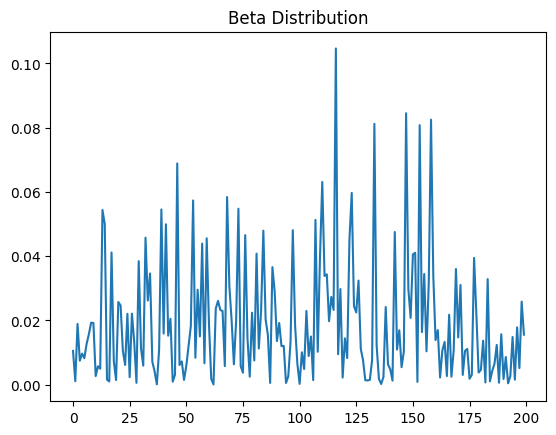

3.82466944883098
Sum of weights: 0.97975469543944


In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

alpha = 2
n = 50
K = 200

# Step 1: generate beta values
beta = np.random.beta(1, alpha + n, size=K)
plt.plot(beta)
plt.title("Beta Distribution")
plt.show()
print(np.sum(beta))

# Step 2: compute stick-breaking weights
pi = np.zeros(K)
remaining = 1

for k in range(K):
    pi[k] = beta[k] * remaining
    remaining *= (1 - beta[k])

print("Sum of weights:", np.sum(pi))

## Generating Atom Locations

Each atom $\theta_k$ is sampled from a mixture of:

$$
\frac{\alpha}{\alpha+n} G_0 + \frac{n}{\alpha+n} \hat{F}_n
$$

where:
- $G_0$: prior distribution,
- $\hat{F}_n$: empirical distribution of data.

---

### Interpretation

- With probability $\frac{\alpha}{\alpha+n}$, we sample from the prior.
- With probability $\frac{n}{\alpha+n}$, we reuse observed data.

This balances:
- exploration (prior)
- exploitation (data)

## Generate Atoms

In [5]:
# Base distribution G0 ~ Normal(2, 0.5)
def sample_G0(size):
    return np.random.normal(2, 0.5, size)

# Sample data
X = np.random.normal(2, 0.5, size=n)

theta = []

for k in range(K):
    if np.random.rand() < alpha / (alpha + n):
        theta.append(sample_G0(1)[0])
    else:
        theta.append(np.random.choice(X))

theta = np.array(theta)

## Spike Representation of the Distribution

The DP realization is discrete:

$$
G = \sum \pi_k \delta_{\theta_k}
$$

This means:
- probability mass is concentrated at points $\theta_k$.
- not spread continuously.

---

### Visualization

We plot:
- x-axis: $\theta_k$ (locations),
- y-axis: $\pi_k$ (weights).

This results in a "spike plot", representing the discrete nature of the distribution.

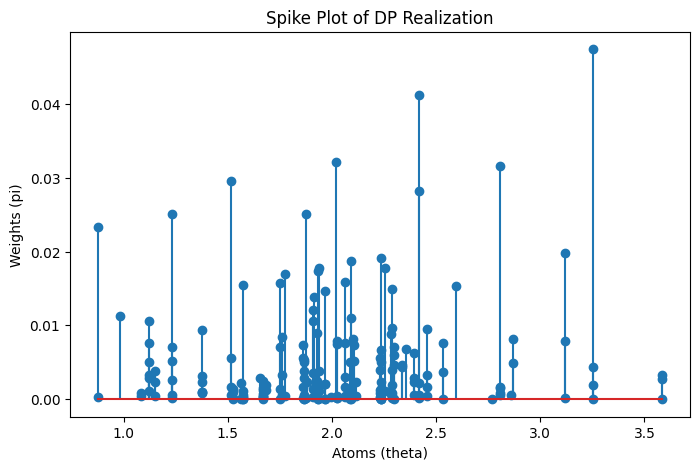

In [9]:
plt.figure(figsize=(8,5))
plt.stem(theta, pi)

plt.title("Spike Plot of DP Realization")
plt.xlabel("Atoms (theta)")
plt.ylabel("Weights (pi)")
plt.show()

## CDF Comparison and Verification

The simulated CDF is:

$$
\hat{G}(t) = \sum_{k=1}^{K} \pi_k \mathbf{1}(\theta_k \le t)
$$

---

The theoretical posterior CDF is:

$$
F_{post}(t) = \frac{\alpha}{\alpha+n} \Phi(t) + \frac{1}{\alpha+n} \sum_{i=1}^n \mathbf{1}(x_i \le t)
$$

---

### Wasserstein Distance

We measure discrepancy using:

$$
W_1 = \int | \hat{G}(t) - F_{post}(t) | dt
$$

---

### Reason for Non-zero Error

- $\hat{G}(t)$ is discrete (step function),
- $F_{post}(t)$ contains a continuous component.

Hence exact equality is impossible even for large $K$.

Wasserstein distance: 0.1669868541917226


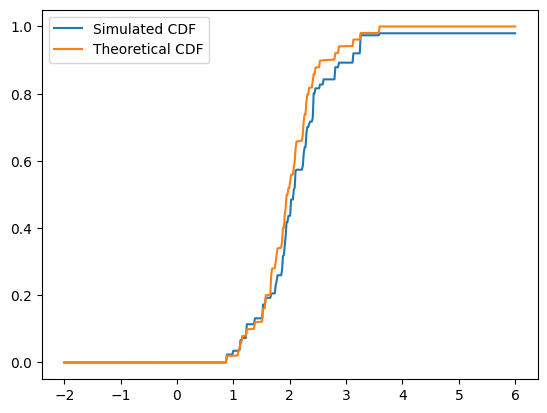

In [11]:
t_vals = np.linspace(-2, 6, 500)

# Simulated CDF
G_hat = [np.sum(pi[theta <= t]) for t in t_vals]

# Theoretical CDF
from scipy.stats import norm

F_post = [(alpha/(alpha+n))*norm.cdf(t, 2, 0.5) +
          (1/(alpha+n))*np.sum(X <= t) for t in t_vals]

# Wasserstein approximation
W1 = np.trapezoid(np.abs(np.array(G_hat) - np.array(F_post)), t_vals)

print("Wasserstein distance:", W1)

plt.plot(t_vals, G_hat, label="Simulated CDF")
plt.plot(t_vals, F_post, label="Theoretical CDF")
plt.legend()
plt.show()

## 15 - Maximum Estimation Problem

We consider data from:

$$
X_i \sim \text{Uniform}(0, 10)
$$

Goal:
Estimate the population maximum.

---

### Issue

For small sample size $n$:
$$
M_n = \max(X_1, ..., X_n)
$$

is biased downward.

---

### Limitation of Bootstrap

Bootstrap samples only from observed data:

$$
M^* \le M_n
$$

Hence:
- no variability,
- no possibility of exceeding $M_n$.

## Generate Data

In [23]:
# Historical data
hist = np.random.uniform(0, 10, 100)
x_bar = np.mean(hist)
s_hist = np.std(hist)
print("Historical mean:", x_bar)
print("Historical std:", s_hist)
# plt.plot(hist, np.zeros_like(hist), 'o')
M = np.max(hist)
print("Historical max:", M)

# Current sample
sample = np.random.uniform(0, 10, 5)
Mn = np.max(sample)

print("Sample max:", Mn)

Historical mean: 4.606311131033499
Historical std: 2.767851155484367
Historical max: 9.588620681972566
Sample max: 9.402987821391688


## DP-Based Bootstrap

We introduce prior uncertainty via:

$$
G_0 \sim \mathcal{N}(\bar{x}_{hist}, s_{hist})
$$

---

### Simulation Procedure

1. Sample:
$$
w_0 \sim \text{Beta}(\alpha, n)
$$

2. Draw new value:
$$
\theta_{new} \sim G_0
$$

3. Compute:
$$
M^* =
\begin{cases}
\max(M_n, \theta_{new}) & \text{with probability } w_0 \\
M_n & \text{otherwise}
\end{cases}
$$

---

### Interpretation

- With probability $w_0$, we trust the prior.
- Otherwise, we retain the observed maximum.

In [28]:
def dp_bootstrap(alpha, n_iter=10000):
    M_star = []

    for _ in range(n_iter):
        w0 = np.random.beta(alpha, 5)
        theta_new = np.random.normal(x_bar, s_hist)

        if np.random.rand() < w0:
            M_star.append(max(Mn, theta_new))
        else:
            M_star.append(Mn)

    return np.array(M_star)

alphas = [0.1, 1.5, 10, 100]
results = {a: dp_bootstrap(a) for a in alphas}

## Analysis

We analyze:

1. Distribution of $M^*$,
2. Breakthrough probability:
$$
P(M^* > M_n)
$$

---

### Expected Behavior

- Small $\alpha$: mostly data-driven → low variability.
- Large $\alpha$: prior-driven → higher variability.

---

### Key Insight

The DP approach allows values beyond $M_n$, unlike classical bootstrap.

Alpha=0.1, P(M*>Mn)=0.0004


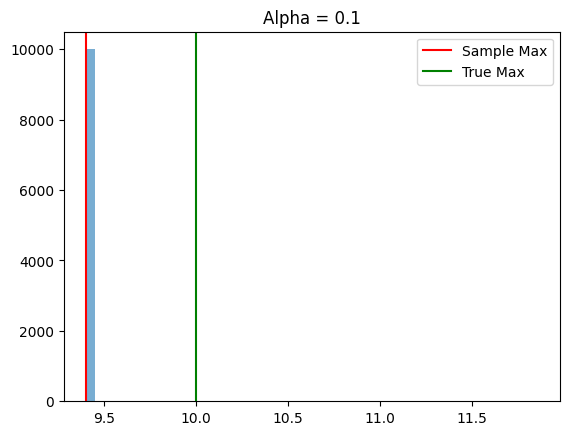

Alpha=1.5, P(M*>Mn)=0.0092


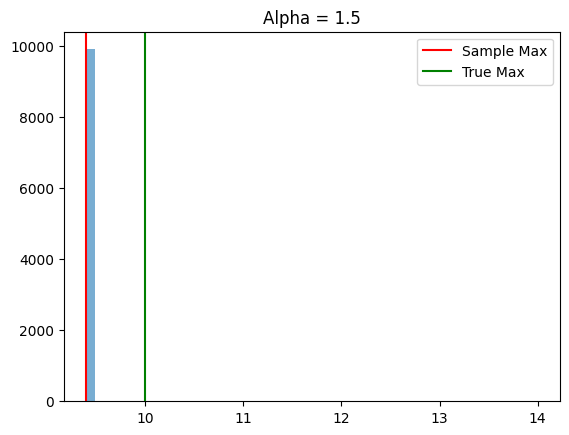

Alpha=10, P(M*>Mn)=0.0277


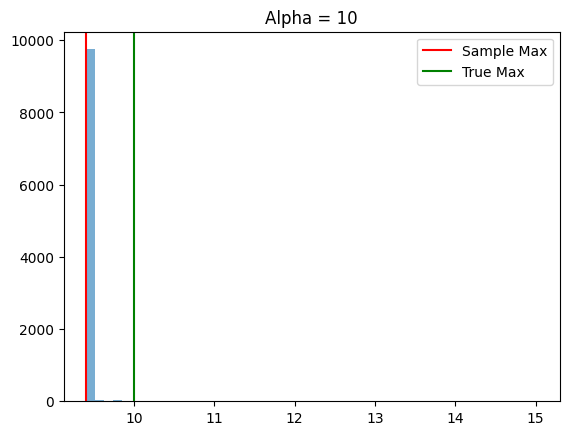

Alpha=100, P(M*>Mn)=0.0409


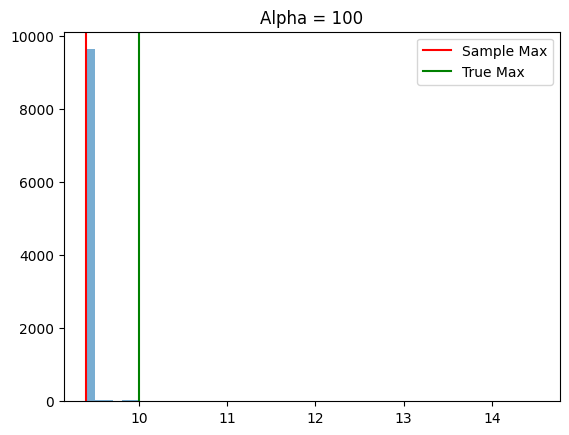

In [29]:
for a in alphas:
    M_star = results[a]

    plt.hist(M_star, bins=50, alpha=0.6)
    plt.axvline(Mn, color='r', label='Sample Max')
    plt.axvline(10, color='g', label='True Max')

    prob = np.mean(M_star > Mn)
    print(f"Alpha={a}, P(M*>Mn)={prob}")

    plt.title(f"Alpha = {a}")
    plt.legend()
    plt.show()

## Conclusions

1. The Dirichlet Process generates discrete distributions represented by weighted atoms.
2. The stick-breaking construction ensures valid probability weights.
3. The simulated distribution approximates the posterior but remains discrete.
4. Classical bootstrap fails for maximum estimation due to lack of extrapolation.
5. DP-based bootstrap incorporates prior information, enabling realistic uncertainty.
6. Increasing $\alpha$ increases prior influence and variability in estimates.

---

## Key Takeaway

The DP framework provides a principled way to combine data and prior knowledge to model uncertainty in both distributions and extreme statistics.